<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1fi3-l8zVpLJj3wj3peImenJzMWBHpo7E" width="850">
</p>


In [ ]:
import gdown
import zipfile
import os

file_id = "1sEzPa5UvadV3Rh4VDuR9tdwvphQa-Af6"
url = f"https://drive.google.com/uc?id={file_id}"
output_zip = "butterfly.zip"

gdown.download(url, output_zip, quiet=False)

extract_dir = "/content"
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

base_dir = os.path.join(extract_dir, "butterfly")
print("Contenido:", os.listdir(base_dir))


Downloading...
From: https://drive.google.com/uc?id=1sEzPa5UvadV3Rh4VDuR9tdwvphQa-Af6
To: /content/butterfly.zip
100%|██████████| 6.43M/6.43M [00:00<00:00, 18.4MB/s]

Contenido: ['train', 'valid']


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_dir = "/content/butterfly"

train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=valid_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Clases:", classes)
print("Num imágenes train:", len(train_dataset))
print("Num imágenes valid:", len(valid_dataset))

num_classes = len(classes)
print("Número de clases:", num_classes)


Device: cuda
Clases: ['AFRICAN GIANT SWALLOWTAIL', 'BECKERS WHITE', 'CATTLEHEART CELLED GREEN', 'CHESTNUT', 'DAPPLE EASTERN WHITE', 'DIAETHRIA ANNA', 'GREY HAIRSTREAK']
Num imágenes train: 433
Num imágenes valid: 159
Número de clases: 7


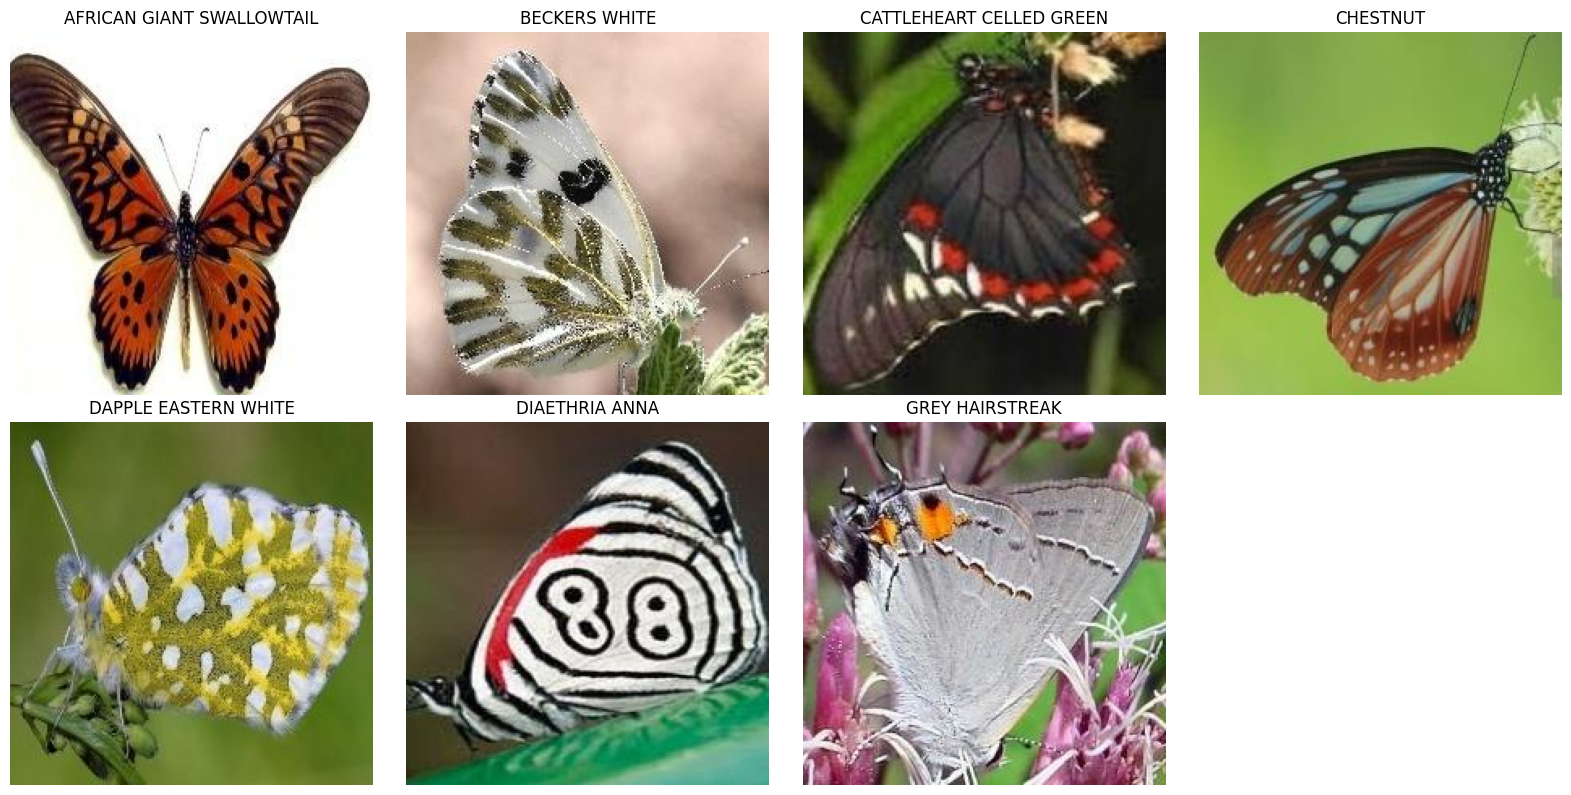

In [ ]:
from PIL import Image

def show_random_images_per_class(dataset, transform, class_names):
    samples_per_class = {cls: [] for cls in class_names}

    for path, label in dataset.samples:
        samples_per_class[class_names[label]].append(path)

    num_classes = len(class_names)
    plt.figure(figsize=(16, 4 * ((num_classes + 3) // 4)))

    for idx, cls in enumerate(class_names):
        img_path = random.choice(samples_per_class[cls])
        img = Image.open(img_path).convert("RGB")

        img_tensor = transform(img)
        img_np = img_tensor.permute(1, 2, 0).numpy()

        plt.subplot((num_classes + 3)//4, 4, idx + 1)
        plt.imshow(img_np)
        plt.title(cls)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images_per_class(train_dataset, valid_transform, train_dataset.classes)


In [ ]:
import torch.nn as nn
from torchvision.models import alexnet, AlexNet_Weights, resnet50, ResNet50_Weights, inception_v3, Inception_V3_Weights, efficientnet_v2_s, EfficientNet_V2_S_Weights

In [ ]:
resnet_random = resnet50(weights=None)
resnet_random

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
efnet_random = efficientnet_v2_s(weights=None)
in_features = efnet_random.classifier[-1].in_features
efnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
efnet_random = efnet_random.to(device)

In [ ]:
# Iniciar con parámetros aleatorios
resnet_random = resnet50(weights=None)
resnet_random.fc = nn.Linear(2048, 7)
resnet_random = resnet_random.to(device)

# Iniciar con parámetros obtenidos con ImageNet
resnet_ft = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
in_features = resnet_random.fc.in_features
resnet_ft.fc = nn.Linear(in_features, num_classes)
resnet_ft = resnet_ft.to(device)

# Iniciar con parámetros obtenidos con ImageNet y congelarlos
resnet_fe = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
for p in resnet_fe.parameters():
    p.requires_grad = False
in_features = resnet_random.fc.in_features
resnet_fe.fc = nn.Linear(in_features, num_classes)
for p in resnet_fe.fc.parameters():
    p.requires_grad = True
resnet_fe = resnet_fe.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


In [ ]:
import torch.nn as nn
from torchvision.models import alexnet, AlexNet_Weights

# Iniciar con parámetros aleatorios
alexnet_random = alexnet(weights=None)
alexnet_random

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
import torch.nn as nn
from torchvision.models import alexnet, AlexNet_Weights

# Iniciar con parámetros aleatorios
alexnet_random = alexnet(weights=None)
in_features = alexnet_random.classifier[-1].in_features
alexnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_random = alexnet_random.to(device)

# Iniciar con parámetros obtenidos con ImageNet
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)

# Iniciar con parámetros obtenidos con ImageNet y congelarlos
alexnet_fe = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
for p in alexnet_fe.parameters():
    p.requires_grad = False
in_features = alexnet_fe.classifier[-1].in_features
alexnet_fe.classifier[-1] = nn.Linear(in_features, num_classes)
for p in alexnet_fe.classifier[-1].parameters():
    p.requires_grad = True
alexnet_fe = alexnet_fe.to(device)


In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score

def entrenar_modelo(model, train_loader, val_loader, num_epochs=10, lr=1e-3, device="cuda"):
    """
    Entrena un modelo PyTorch con seguimiento de métricas.

    Parámetros:
        model        -> instancia del modelo (nn.Module)
        train_loader -> DataLoader para entrenamiento
        val_loader   -> DataLoader para validación
        num_epochs   -> número de épocas
        lr           -> learning rate
        device       -> 'cuda' o 'cpu'

    Retorna:
        history -> diccionario con loss, acc, f1 de train y val.
    """

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    parametros_para_optimizar = [p for p in model.parameters() if p.requires_grad==True]
    optimizer = optim.SGD(parametros_para_optimizar, lr=lr, momentum=0)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }

    for epoch in range(num_epochs):

        # ----------------------------------------
        # ENTRENAMIENTO
        # ----------------------------------------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        preds_train = []
        labels_train = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            preds_train.extend(predicted.detach().cpu().numpy())
            labels_train.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(labels_train, preds_train, average="macro")

        # ----------------------------------------
        # VALIDACIÓN
        # ----------------------------------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        preds_val = []
        labels_val = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                preds_val.extend(predicted.detach().cpu().numpy())
                labels_val.extend(labels.detach().cpu().numpy())

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(labels_val, preds_val, average="macro")

        # Guardar métricas
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  "
            f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
            f"Train F1: {train_f1:.4f}  Val F1: {val_f1:.4f}"
        )

    return history


In [ ]:
num_epochs = 20
history = entrenar_modelo(resnet_random, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Epoch [1/20] Train Loss: 1.9319  Val Loss: 1.9372  Train Acc: 0.1478  Val Acc: 0.1887  Train F1: 0.1008  Val F1: 0.0454
Epoch [2/20] Train Loss: 1.8937  Val Loss: 1.9611  Train Acc: 0.1640  Val Acc: 0.1824  Train F1: 0.1407  Val F1: 0.0624
Epoch [3/20] Train Loss: 1.8839  Val Loss: 1.9444  Train Acc: 0.1848  Val Acc: 0.2013  Train F1: 0.1664  Val F1: 0.0695
Epoch [4/20] Train Loss: 1.8760  Val Loss: 1.8498  Train Acc: 0.2055  Val Acc: 0.1950  Train F1: 0.2063  Val F1: 0.1478
Epoch [5/20] Train Loss: 1.8363  Val Loss: 1.8499  Train Acc: 0.2171  Val Acc: 0.3019  Train F1: 0.2260  Val F1: 0.2272
Epoch [6/20] Train Loss: 1.8112  Val Loss: 1.9416  Train Acc: 0.2171  Val Acc: 0.1509  Train F1: 0.1946  Val F1: 0.0885
Epoch [7/20] Train Loss: 1.8292  Val Loss: 2.7290  Train Acc: 0.2102  Val Acc: 0.1635  Train F1: 0.2030  Val F1: 0.0611
Epoch [8/20] Train Loss: 1.8506  Val Loss: 1.9097  Train Acc: 0.1940  Val Acc: 0.2201  Train F1: 0.1760  Val F1: 0.1521
Epoch [9/20] Train Loss: 1.7958  Val Los

KeyboardInterrupt: 

Epoch [1/20] Train Loss: 1.9088  Val Loss: 1.8554  Train Acc: 0.1871  Val Acc: 0.2327  Train F1: 0.1497  Val F1: 0.2333
Epoch [2/20] Train Loss: 1.7682  Val Loss: 1.7245  Train Acc: 0.4134  Val Acc: 0.4969  Train F1: 0.3926  Val F1: 0.5136
Epoch [3/20] Train Loss: 1.6433  Val Loss: 1.5991  Train Acc: 0.6443  Val Acc: 0.6101  Train F1: 0.6360  Val F1: 0.6077
Epoch [4/20] Train Loss: 1.5072  Val Loss: 1.4773  Train Acc: 0.7390  Val Acc: 0.7170  Train F1: 0.7363  Val F1: 0.7179
Epoch [5/20] Train Loss: 1.4184  Val Loss: 1.3701  Train Acc: 0.8129  Val Acc: 0.7736  Train F1: 0.8078  Val F1: 0.7757
Epoch [6/20] Train Loss: 1.3101  Val Loss: 1.2627  Train Acc: 0.8453  Val Acc: 0.8176  Train F1: 0.8422  Val F1: 0.8197
Epoch [7/20] Train Loss: 1.1953  Val Loss: 1.1663  Train Acc: 0.9099  Val Acc: 0.8365  Train F1: 0.9095  Val F1: 0.8368
Epoch [8/20] Train Loss: 1.0876  Val Loss: 1.0717  Train Acc: 0.9215  Val Acc: 0.8553  Train F1: 0.9217  Val F1: 0.8555
Epoch [9/20] Train Loss: 0.9972  Val Los

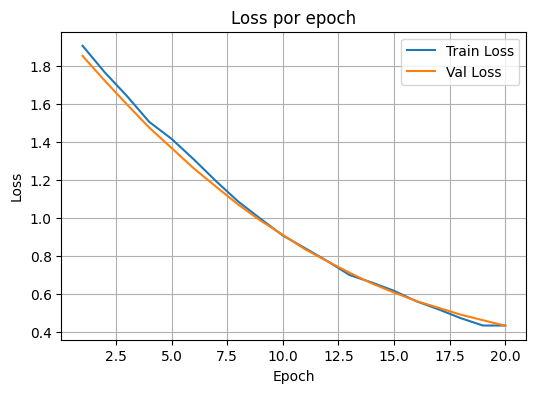

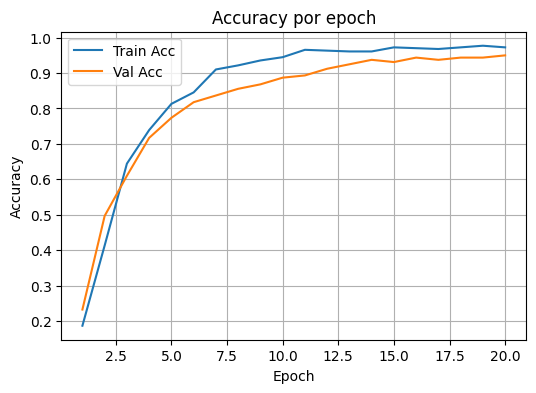

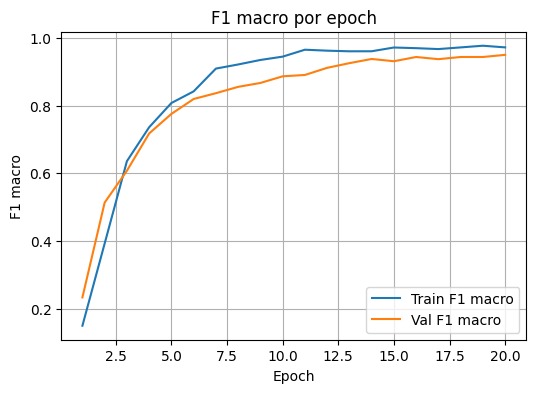

In [ ]:
import torch.nn as nn
from torchvision.models import alexnet, AlexNet_Weights

# Iniciar con parámetros obtenidos con ImageNet
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)


num_epochs = 20
history = entrenar_modelo(resnet_ft, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Epoch [1/20] Train Loss: 1.4487  Val Loss: 0.9561  Train Acc: 0.5173  Val Acc: 0.8365  Train F1: 0.5228  Val F1: 0.8386
Epoch [2/20] Train Loss: 0.8567  Val Loss: 0.6563  Train Acc: 0.7829  Val Acc: 0.8805  Train F1: 0.7832  Val F1: 0.8792
Epoch [3/20] Train Loss: 0.6172  Val Loss: 0.5058  Train Acc: 0.8776  Val Acc: 0.9119  Train F1: 0.8785  Val F1: 0.9135
Epoch [4/20] Train Loss: 0.4863  Val Loss: 0.4215  Train Acc: 0.9007  Val Acc: 0.9434  Train F1: 0.9020  Val F1: 0.9434
Epoch [5/20] Train Loss: 0.4231  Val Loss: 0.3830  Train Acc: 0.9192  Val Acc: 0.9182  Train F1: 0.9206  Val F1: 0.9179
Epoch [6/20] Train Loss: 0.3504  Val Loss: 0.3449  Train Acc: 0.9515  Val Acc: 0.9245  Train F1: 0.9518  Val F1: 0.9250
Epoch [7/20] Train Loss: 0.3423  Val Loss: 0.3018  Train Acc: 0.9469  Val Acc: 0.9371  Train F1: 0.9475  Val F1: 0.9367
Epoch [8/20] Train Loss: 0.3153  Val Loss: 0.2945  Train Acc: 0.9376  Val Acc: 0.9371  Train F1: 0.9380  Val F1: 0.9376
Epoch [9/20] Train Loss: 0.2971  Val Los

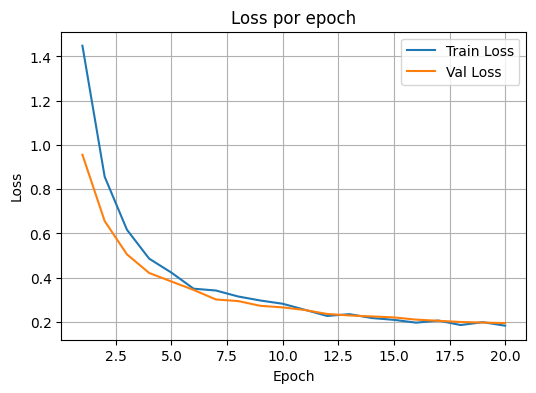

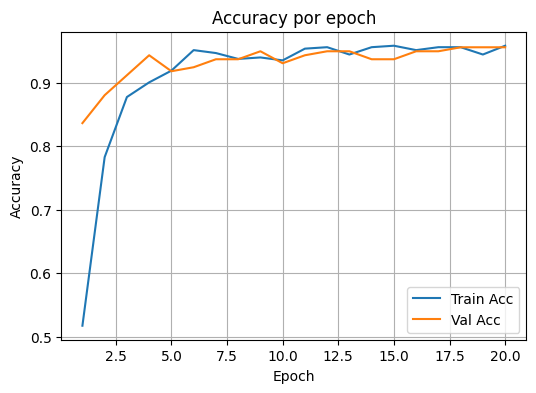

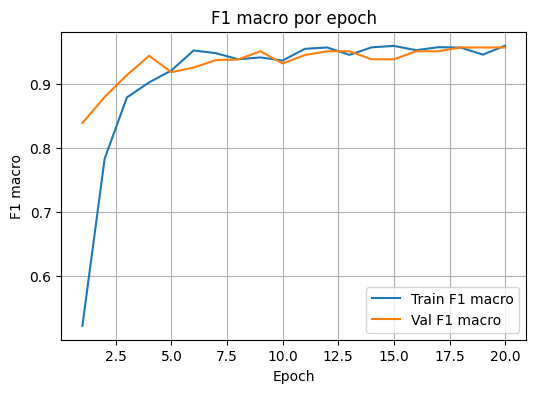

In [ ]:
num_epochs = 20
history = entrenar_modelo(alexnet_fe, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Epoch [1/20] Train Loss: 1.4940  Val Loss: 1.0888  Train Acc: 0.4781  Val Acc: 0.6352  Train F1: 0.4753  Val F1: 0.6355
Epoch [2/20] Train Loss: 0.6980  Val Loss: 0.4920  Train Acc: 0.8984  Val Acc: 0.9686  Train F1: 0.8999  Val F1: 0.9692
Epoch [3/20] Train Loss: 0.4184  Val Loss: 0.3497  Train Acc: 0.9330  Val Acc: 0.9434  Train F1: 0.9327  Val F1: 0.9451
Epoch [4/20] Train Loss: 0.3443  Val Loss: 0.2548  Train Acc: 0.9353  Val Acc: 0.9560  Train F1: 0.9357  Val F1: 0.9553
Epoch [5/20] Train Loss: 0.2556  Val Loss: 0.2126  Train Acc: 0.9561  Val Acc: 0.9748  Train F1: 0.9564  Val F1: 0.9744
Epoch [6/20] Train Loss: 0.2076  Val Loss: 0.1792  Train Acc: 0.9654  Val Acc: 0.9686  Train F1: 0.9655  Val F1: 0.9682
Epoch [7/20] Train Loss: 0.2032  Val Loss: 0.1797  Train Acc: 0.9700  Val Acc: 0.9686  Train F1: 0.9702  Val F1: 0.9686
Epoch [8/20] Train Loss: 0.1464  Val Loss: 0.1550  Train Acc: 0.9838  Val Acc: 0.9686  Train F1: 0.9837  Val F1: 0.9685
Epoch [9/20] Train Loss: 0.1403  Val Los

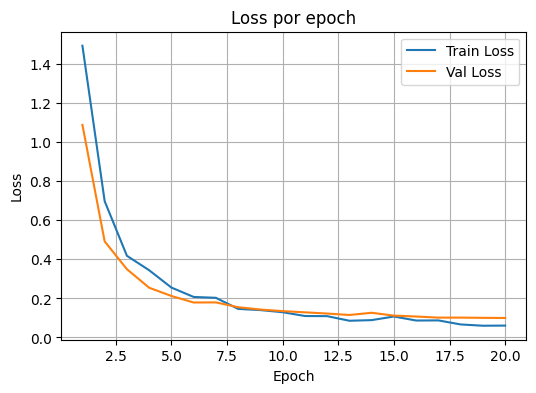

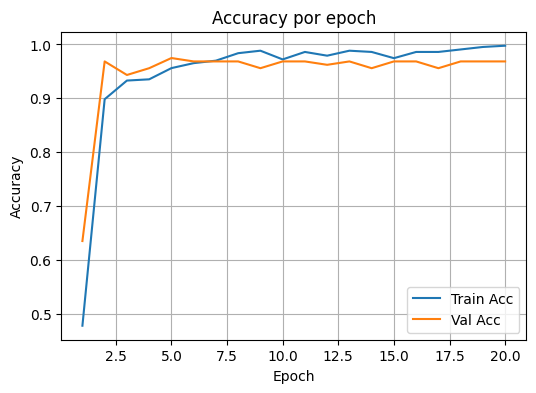

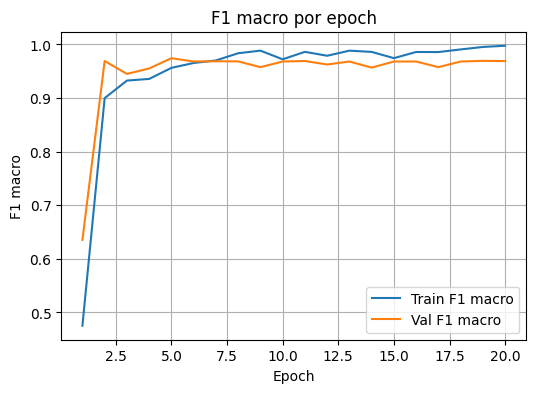

In [ ]:
num_epochs = 20
history = entrenar_modelo(resnet_fe, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Epoch [1/20] Train Loss: 2.2638  Val Loss: 1.9493  Train Acc: 0.1617  Val Acc: 0.1069  Train F1: 0.0575  Val F1: 0.0276
Epoch [2/20] Train Loss: 1.9235  Val Loss: 1.8870  Train Acc: 0.1501  Val Acc: 0.1132  Train F1: 0.0578  Val F1: 0.0496
Epoch [3/20] Train Loss: 1.9379  Val Loss: 1.9114  Train Acc: 0.1547  Val Acc: 0.1447  Train F1: 0.0856  Val F1: 0.0487
Epoch [4/20] Train Loss: 1.8130  Val Loss: 1.6706  Train Acc: 0.2517  Val Acc: 0.2767  Train F1: 0.1378  Val F1: 0.1650
Epoch [5/20] Train Loss: 1.5682  Val Loss: 1.3996  Train Acc: 0.3141  Val Acc: 0.4277  Train F1: 0.2901  Val F1: 0.3228
Epoch [6/20] Train Loss: 1.4047  Val Loss: 1.5561  Train Acc: 0.4411  Val Acc: 0.4151  Train F1: 0.3831  Val F1: 0.3420
Epoch [7/20] Train Loss: 1.5172  Val Loss: 1.2859  Train Acc: 0.3788  Val Acc: 0.4277  Train F1: 0.3377  Val F1: 0.3755
Epoch [8/20] Train Loss: 1.2161  Val Loss: 1.1674  Train Acc: 0.4734  Val Acc: 0.5283  Train F1: 0.4497  Val F1: 0.4451
Epoch [9/20] Train Loss: 1.1543  Val Los

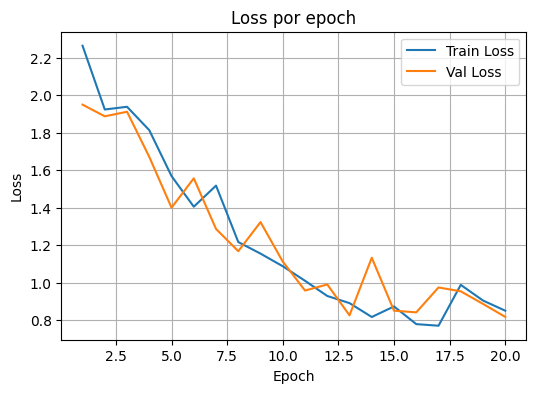

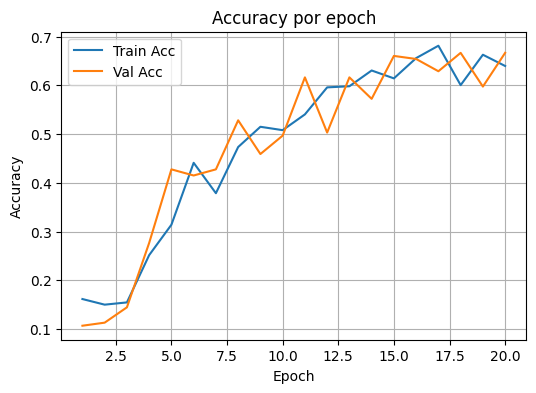

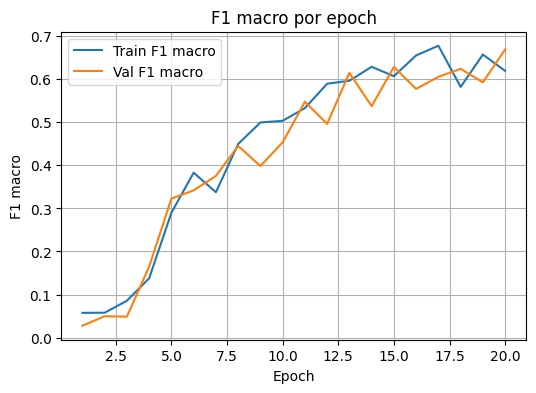

In [ ]:
num_epochs = 20
history = entrenar_modelo(alexnet_random, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Epoch [1/20] Train Loss: 1.3970  Val Loss: 0.8448  Train Acc: 0.5266  Val Acc: 0.8050  Train F1: 0.5242  Val F1: 0.7919
Epoch [2/20] Train Loss: 0.6608  Val Loss: 0.4541  Train Acc: 0.8430  Val Acc: 0.8931  Train F1: 0.8418  Val F1: 0.8883
Epoch [3/20] Train Loss: 0.4227  Val Loss: 0.3467  Train Acc: 0.8822  Val Acc: 0.9182  Train F1: 0.8838  Val F1: 0.9155
Epoch [4/20] Train Loss: 0.2997  Val Loss: 0.2684  Train Acc: 0.9353  Val Acc: 0.9119  Train F1: 0.9358  Val F1: 0.9099
Epoch [5/20] Train Loss: 0.2271  Val Loss: 0.2811  Train Acc: 0.9538  Val Acc: 0.8994  Train F1: 0.9538  Val F1: 0.9011
Epoch [6/20] Train Loss: 0.1992  Val Loss: 0.2131  Train Acc: 0.9423  Val Acc: 0.9182  Train F1: 0.9430  Val F1: 0.9184
Epoch [7/20] Train Loss: 0.1556  Val Loss: 0.1710  Train Acc: 0.9538  Val Acc: 0.9371  Train F1: 0.9538  Val F1: 0.9376
Epoch [8/20] Train Loss: 0.1483  Val Loss: 0.2086  Train Acc: 0.9607  Val Acc: 0.9245  Train F1: 0.9606  Val F1: 0.9249
Epoch [9/20] Train Loss: 0.1336  Val Los

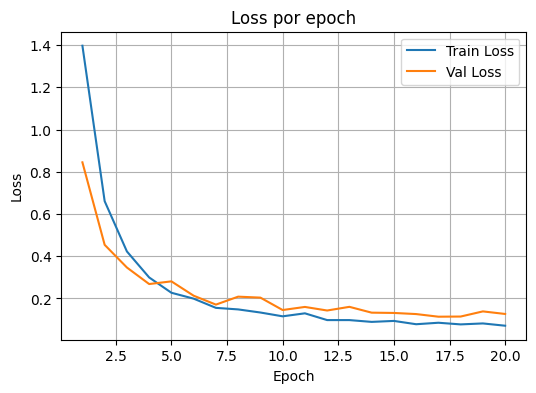

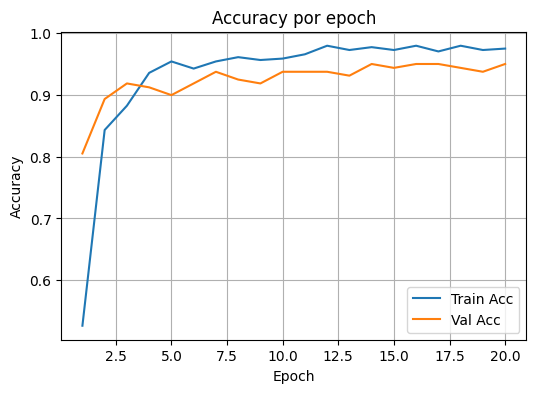

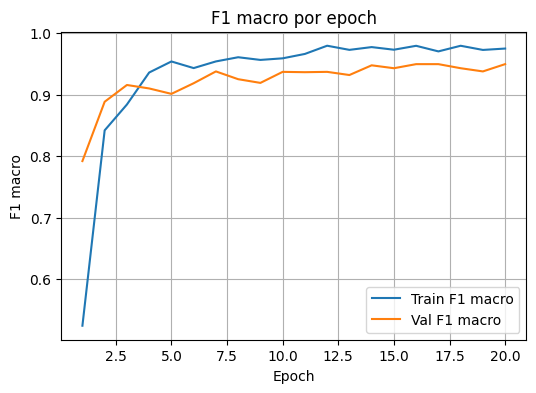

In [ ]:
# Iniciar con parámetros obtenidos con ImageNet
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)

num_epochs = 20
history = entrenar_modelo(alexnet_ft, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Epoch [1/20] Train Loss: 0.7133  Val Loss: 0.2211  Train Acc: 0.7783  Val Acc: 0.9245  Train F1: 0.7805  Val F1: 0.9267
Epoch [2/20] Train Loss: 0.1775  Val Loss: 0.1534  Train Acc: 0.9400  Val Acc: 0.9434  Train F1: 0.9400  Val F1: 0.9451
Epoch [3/20] Train Loss: 0.1174  Val Loss: 0.1487  Train Acc: 0.9538  Val Acc: 0.9371  Train F1: 0.9542  Val F1: 0.9407
Epoch [4/20] Train Loss: 0.0881  Val Loss: 0.1059  Train Acc: 0.9792  Val Acc: 0.9623  Train F1: 0.9793  Val F1: 0.9628
Epoch [5/20] Train Loss: 0.0772  Val Loss: 0.1850  Train Acc: 0.9792  Val Acc: 0.9245  Train F1: 0.9793  Val F1: 0.9270
Epoch [6/20] Train Loss: 0.0718  Val Loss: 0.1047  Train Acc: 0.9723  Val Acc: 0.9686  Train F1: 0.9722  Val F1: 0.9686
Epoch [7/20] Train Loss: 0.0743  Val Loss: 0.1524  Train Acc: 0.9792  Val Acc: 0.9434  Train F1: 0.9796  Val F1: 0.9453
Epoch [8/20] Train Loss: 0.0610  Val Loss: 0.1366  Train Acc: 0.9815  Val Acc: 0.9497  Train F1: 0.9816  Val F1: 0.9512
Epoch [9/20] Train Loss: 0.0541  Val Los

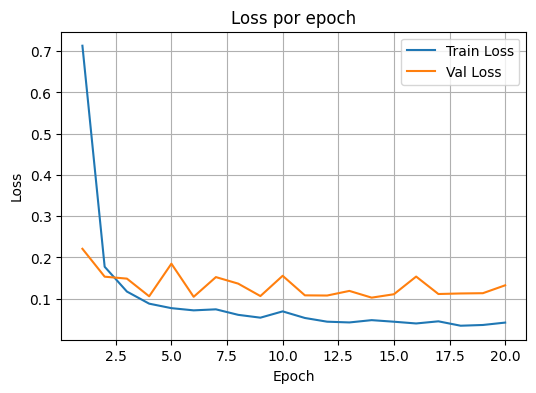

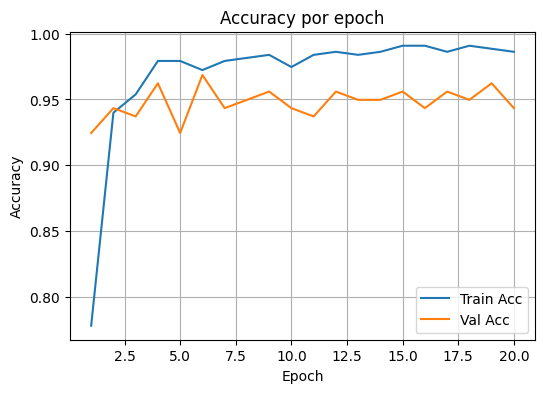

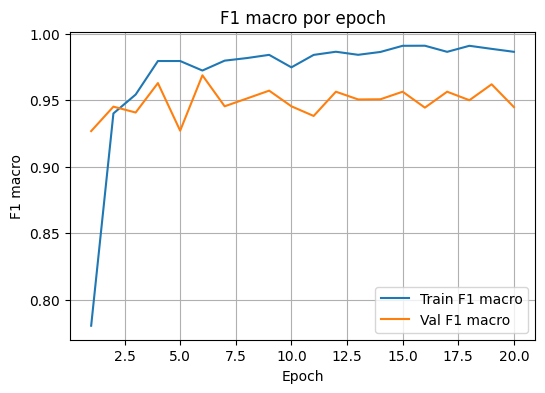

In [ ]:
num_epochs = 20
history = entrenar_modelo(alexnet_fe, train_loader, valid_loader, num_epochs)

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Predicción: AFRICAN GIANT SWALLOWTAIL (36.78 %)


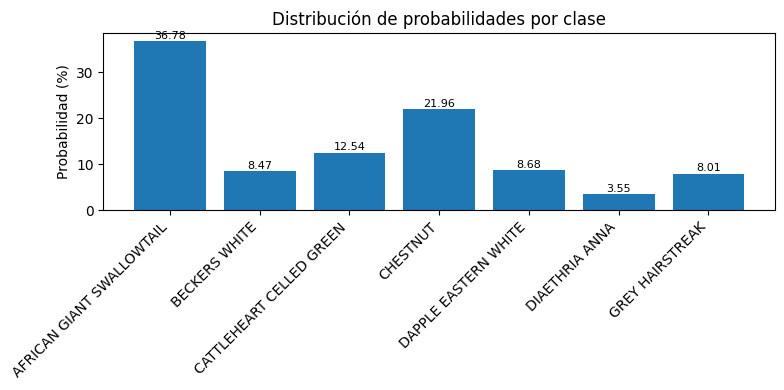

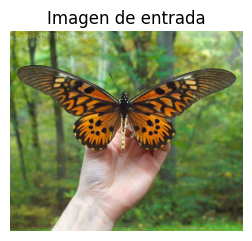

In [ ]:
from PIL import Image
import numpy as np

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def infer_image(path_img, model, classes):
    model.eval()
    img = Image.open(path_img).convert("RGB")
    x = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    predicted_idx = int(np.argmax(probs))
    predicted_class = classes[predicted_idx]

    print(f"Predicción: {predicted_class} ({probs[predicted_idx] * 100:.2f} %)")

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(len(classes)), probs * 100)
    plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
    plt.ylabel("Probabilidad (%)")
    plt.title("Distribución de probabilidades por clase")

    for i, p in enumerate(probs * 100):
        plt.text(i, p + 0.5, f"{p:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Imagen de entrada")
    plt.show()


infer_image("/content/122448244_2748943502033073_5458906956555871184_n.jpg", resnet_ft, classes)
